In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import os

os.chdir(r"c:\Users\emerd\Desktop\repos\churn-prediction")

# Cargar datos
import sys
sys.path.append('src')
from src.train import load_data, build_pipeline

df = load_data('data/Churn_Modelling.csv')
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar pipeline
pipeline = build_pipeline()
pipeline.fit(X_train, y_train)

print("Listo ✓")

Listo ✓


In [3]:
# Obtener probabilidades
y_proba = pipeline.predict_proba(X_test)[:,1]

# Probar diferentes thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred_t = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    results.append({
        'threshold': threshold,
        'recall_churn': report['1']['recall'],
        'precision_churn': report['1']['precision'],
        'f1_churn': report['1']['f1-score']
    })

results_df = pd.DataFrame(results)
print(results_df)

    threshold  recall_churn  precision_churn  f1_churn
0        0.10      0.894349         0.326457  0.478318
1        0.15      0.828010         0.396938  0.536624
2        0.20      0.771499         0.445390  0.564748
3        0.25      0.727273         0.513889  0.602238
4        0.30      0.670762         0.575949  0.619750
5        0.35      0.606880         0.617500  0.612144
6        0.40      0.567568         0.691617  0.623482
7        0.45      0.511057         0.740214  0.604651
8        0.50      0.459459         0.782427  0.578947
9        0.55      0.402948         0.815920  0.539474
10       0.60      0.371007         0.848315  0.516239
11       0.65      0.334152         0.855346  0.480565
12       0.70      0.292383         0.908397  0.442379
13       0.75      0.248157         0.901786  0.389210
14       0.80      0.181818         0.913580  0.303279
15       0.85      0.130221         0.963636  0.229437


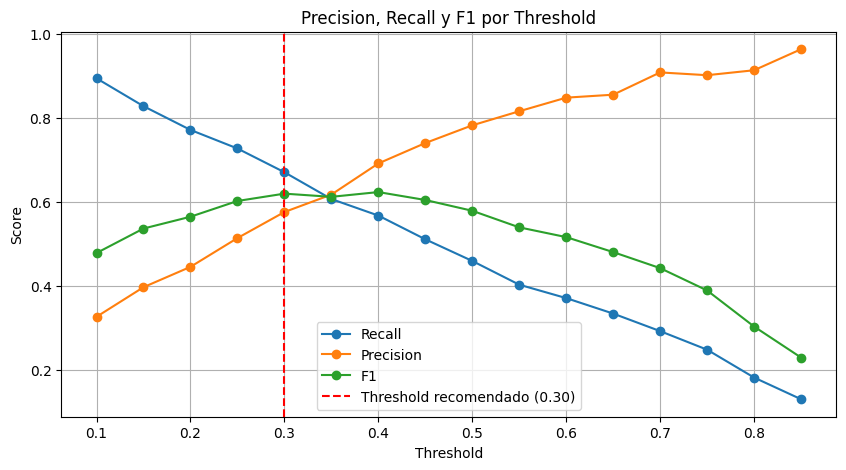

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(results_df['threshold'], results_df['recall_churn'], label='Recall', marker='o')
plt.plot(results_df['threshold'], results_df['precision_churn'], label='Precision', marker='o')
plt.plot(results_df['threshold'], results_df['f1_churn'], label='F1', marker='o')
plt.axvline(x=0.30, color='red', linestyle='--', label='Threshold recomendado (0.30)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall y F1 por Threshold')
plt.legend()
plt.grid()
plt.show()

In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Necesitamos preprocesar primero antes de aplicar SMOTE
# porque SMOTE solo trabaja con datos numéricos
categorical_cols = ['Geography', 'Gender']
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                  'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                  'EstimatedSalary']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# Pipeline con SMOTE — usamos ImbPipeline que soporta samplers
pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_smote.fit(X_train, y_train)

y_pred_smote = pipeline_smote.predict(X_test)
y_proba_smote = pipeline_smote.predict_proba(X_test)[:,1]

print("=== Pipeline con SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_smote))

=== Pipeline con SMOTE ===
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1593
           1       0.64      0.57      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000

AUC-ROC: 0.8498768414022652


In [6]:
thresholds = np.arange(0.1, 0.9, 0.05)
results_smote = []

for threshold in thresholds:
    y_pred_t = (y_proba_smote >= threshold).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    results_smote.append({
        'threshold': threshold,
        'recall_churn': report['1']['recall'],
        'precision_churn': report['1']['precision'],
        'f1_churn': report['1']['f1-score']
    })

results_smote_df = pd.DataFrame(results_smote)
print(results_smote_df)

    threshold  recall_churn  precision_churn  f1_churn
0        0.10      0.948403         0.299457  0.455189
1        0.15      0.877150         0.343269  0.493435
2        0.20      0.840295         0.382123  0.525346
3        0.25      0.796069         0.430279  0.558621
4        0.30      0.761671         0.468986  0.580524
5        0.35      0.722359         0.516696  0.602459
6        0.40      0.660934         0.558091  0.605174
7        0.45      0.626536         0.608592  0.617433
8        0.50      0.570025         0.637363  0.601816
9        0.55      0.535627         0.674923  0.597260
10       0.60      0.476658         0.685512  0.562319
11       0.65      0.429975         0.729167  0.540958
12       0.70      0.373464         0.779487  0.504983
13       0.75      0.321867         0.818750  0.462081
14       0.80      0.235872         0.842105  0.368522
15       0.85      0.167076         0.860759  0.279835
